In [1]:
# Trước hết, chúng ta import một số thư viện cần thiết đã
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import random

# Số classes trong tập MNIST
num_classes = 10
# Số epoch
epochs = 5
# Các tham số cần thiết cho quá trình traning.
learning_rate = 0.001
batch_size = 128
display_step = 50
# Path lưu best model

checkpoint = 'model.pth' # có thể để dạng *.pth

# device chúng ta dùng cuda
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# assert device == 'cuda'

In [2]:
# Transform image
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
    ])
# load dataset từ torchvision.datasets
train_dataset = datasets.MNIST('../data', train=True, download=True,transform=transform)
test_dataset = datasets.MNIST('../data', train=False,transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset,batch_size=batch_size)
test_loader = torch.utils.data.DataLoader(test_dataset,batch_size=batch_size)

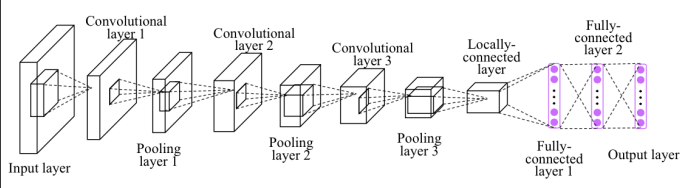

In [3]:
class Net(nn.Module):
  def __init__(self):
    super(Net,self).__init__()
    self.dropout = nn.Dropout(0.3)
    self.relu = nn.ReLU()

    # in_chanels, out_chanels, kernal_size, stride, padding
    self.conv1 = nn.Conv2d(1,32,3,1)
    # 1 * 28 * 28 -> 32 * 26 * 26
    #kernal size, stride, padding
    self.maxpool1 = nn.MaxPool2d(2)
    # 32 * 13 * 13
    self.conv2 = nn.Conv2d(32,64,3,1)
    # 64 * 11 * 11
    self.maxpool2 = nn.MaxPool2d(2)
    # 64 * 5 * 5
    self.conv3 = nn.Conv2d(64,64,3,1)
    # 64 * 3 * 3
    self.maxpool3 = nn.MaxPool2d(2)
    # 64 * 1 * 1
    # infeature,outfeature
    self.fc1 = nn.Linear(64,64)
    self.fc2 = nn.Linear(64,32)
    self.fc3 = nn.Linear(32,num_classes)
  def forward(self,x):
    x = self.conv1(x)
    x = self.relu(x)
    x = self.maxpool1(x)
    x = self.conv2(x)
    x = self.relu(x)
    x = self.maxpool2(x)
    x = self.conv3(x)
    x = self.relu(x)
    x = self.maxpool3(x)
    x = self.dropout(x)
    x = nn.Flatten()(x)
    x = self.fc1(x)
    x = self.relu(x)
    x = self.dropout(x)
    x = self.fc2(x)
    x = self.relu(x)
    x = self.dropout(x)
    x = self.fc3(x)
    return x


In [4]:
# call model
model = Net().to(device)
# load lại pretrained model (nếu có)
try:
  model.load_state_dict(torch.load(checkpoint))
except:
  print("!!! Hãy train để có checkpoint file")


In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
best_val_loss = 999
for epoch in range(1,epochs):
    # Quá trình training
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output,target)
        loss.backward()
        optimizer.step()
        if batch_idx % display_step == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tTrain Loss: {:.6f}'.format(epoch, batch_idx * len(data), len(train_loader.dataset),  100. * batch_idx / len(train_loader), loss.item()))

# Quá trình testing
model.eval()
test_loss = 0
correct = 0
# set no grad cho quá trình testing
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        output = F.log_softmax(output,dim=1) # log softmax using F, chu y dim
        test_loss += criterion(output,target)
        pred = output.argmax(dim = 1,keepdim = True) # argmax để lấy predicted
        correct += pred.eq(target.view_as(pred)).sum().item()
test_loss /= len(test_loader.dataset)
if test_loss < best_val_loss:
  best_val_loss = test_loss
  torch.save(model.state_dict(), checkpoint)  # Lưu lại model
  print("***********    TEST_ACC = {}%    ***********".format(correct))

Train Epoch: 1 [0/60000 (0%)]	Train Loss: 0.065826
Train Epoch: 1 [6400/60000 (11%)]	Train Loss: 0.260269
Train Epoch: 1 [12800/60000 (21%)]	Train Loss: 0.207317
Train Epoch: 1 [19200/60000 (32%)]	Train Loss: 0.217818
Train Epoch: 1 [25600/60000 (43%)]	Train Loss: 0.120412
Train Epoch: 1 [32000/60000 (53%)]	Train Loss: 0.076217
Train Epoch: 1 [38400/60000 (64%)]	Train Loss: 0.204291
Train Epoch: 1 [44800/60000 (75%)]	Train Loss: 0.118417
Train Epoch: 1 [51200/60000 (85%)]	Train Loss: 0.158795
Train Epoch: 1 [57600/60000 (96%)]	Train Loss: 0.176143
Train Epoch: 2 [0/60000 (0%)]	Train Loss: 0.079946
Train Epoch: 2 [6400/60000 (11%)]	Train Loss: 0.204838
Train Epoch: 2 [12800/60000 (21%)]	Train Loss: 0.099756
Train Epoch: 2 [19200/60000 (32%)]	Train Loss: 0.109741
Train Epoch: 2 [25600/60000 (43%)]	Train Loss: 0.159571
Train Epoch: 2 [32000/60000 (53%)]	Train Loss: 0.116210
Train Epoch: 2 [38400/60000 (64%)]	Train Loss: 0.108096
Train Epoch: 2 [44800/60000 (75%)]	Train Loss: 0.069596
Trai

In [6]:
# load lại model đã train
model.load_state_dict(torch.load(checkpoint))
# set eval phase
model.eval()


Net(
  (dropout): Dropout(p=0.3, inplace=False)
  (relu): ReLU()
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
  (maxpool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=64, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=10, bias=True)
)

In [7]:
item = iter(test_loader)


In [8]:
# thử predict
def plot(data,model):
  data = torch.unsqueeze(data,dim=0).to(device) # unsqueeze data
  output = model(data)
  output = F.log_softmax(output,dim=1) # log softmax, chú ý dim
  pred = output.argmax(dim=1,keepdim=True) # argmax, chú ý keepdim
  print("Predict Number : ", pred[0][0].detach().cpu().numpy())
  plt.imshow(data[0][0].detach().cpu().numpy(),cmap='gray')
  plt.show()


Predict Number :  9


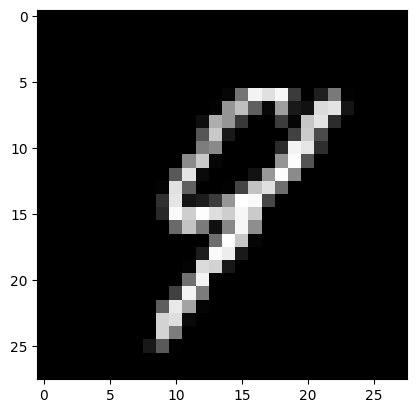

In [9]:
data, target = next(item) # Sử dụng next(item) thay vì item.next()
test_idx = random.choice(range(len(data))) # lấy index của một phần tử của một batch
data = data[test_idx]
target = target[test_idx]
assert data.shape == (1,28,28)
plot(data, model)